In [ ]:
# --- Bibliotecas Estándar de Python ---
import os
import pickle
import random
from collections import Counter

# --- Bibliotecas de Ciencia de Datos y Gráficos ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# --- TensorFlow (Núcleo) ---
import tensorflow as tf

# --- Utilidades de Scikit-learn ---
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# --- TensorFlow Keras (Modelos y Aplicaciones) ---
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import MobileNetV2

# --- TensorFlow Keras (Capas) ---
# (Se incluyen las capas de Aumento de Datos de la celda 11)
from tensorflow.keras.layers import (
    Input, Dense, Dropout,
    GlobalAveragePooling2D, RandomFlip,
    RandomRotation, RandomZoom
)

# --- TensorFlow Keras (Componentes de Entrenamiento) ---
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta
path_pokemon = '/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/pokemonDB_dataset.csv'

# Carga de datos
df = pd.read_csv(path_pokemon)

# Dividir los tipos múltiples en listas
listas_de_tipos = df['Type'].str.split(',')

conteo_tipos = Counter()

for lista in listas_de_tipos:
        # Creamos una lista limpia para cada Pokémon
        tipos_limpios = []
        for tipo in lista:
            # .strip() elimina espacios en blanco al inicio o final
            # ej. " Ice" -> "Ice"
            tipos_limpios.append(tipo.strip())

        # Actualizamos el conteo con los tipos limpios
        conteo_tipos.update(tipos_limpios)

In [ ]:
#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon1"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Images DB.zip" "/content/pokemon1.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon1.zip -d /content/pokemon1
  print("¡Dataset listo en /content/pokemon1!")
else:
  print("El dataset ya está en /content/pokemon1")

#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon2"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Pokemon Dataset.zip" "/content/pokemon2.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon2.zip -d /content/pokemon2
  print("¡Dataset listo en /content/pokemon2!")
else:
  print("El dataset ya está en /content/pokemon2")

#---------------------------------------------------------------------------------------------------------------

if not os.path.exists("/content/pokemon3"):
  print("Copiando dataset de Drive a Colab...")
  !cp "/content/drive/MyDrive/Colab Notebooks/Pokemon/Datos/Fotos Pokemon1.zip" "/content/pokemon3.zip"
  print("¡Copia finalizada!")

  print("Descomprimiendo dataset...")
  !unzip -q /content/pokemon3.zip -d /content/pokemon3
  print("¡Dataset listo en /content/pokemon3!")
else:
  print("El dataset ya está en /content/pokemon3")

#---------------------------------------------------------------------------------------------------------------

Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon1!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon2!
Copiando dataset de Drive a Colab...
¡Copia finalizada!
Descomprimiendo dataset...
¡Dataset listo en /content/pokemon3!


In [ ]:
def normalize_name(name):
    """
    Limpia un nombre de Pokémon para que coincida
    entre el CSV y los nombres de las carpetas.
    """
    if not isinstance(name, str):
        name = str(name)

    # Convertir a minúsculas PRIMERO
    name = name.lower()

    # 2. Quitar paréntesis y espacios
    name = name.replace("(", "").replace(")", "")

    # 3. Reemplazar caracteres especiales
    name = name.replace('♀', '-f')       # nidoran♀ -> nidoran-f
    name = name.replace('♂', '-m')       # nidoran♂ -> nidoran-m
    name = name.replace("'", "")       # farfetch'd -> farfetchd
    name = name.replace(".", "")       # mime jr. -> mimejr
    name = name.replace("_", "-")      # farfetch_d -> farfetch-d
    name = name.replace(" ", "")       # Mime Jr. -> mimejr (manejado por .lower() y replace)
    name = name.replace(":", "")       # Type: Null -> typenull

    return name

    print("Creando mapa de etiquetas normalizado...")

label_map = {}

for index, row in df.iterrows():

    # Obtener el nombre "sucio" del CSV
    nombre_pokemon_csv = row['Pokemon']

    # Manejar los casos especiales de Nidoran

    if "Nidoran♀ (female)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♀"
    elif "Nidoran♂ (male)" in nombre_pokemon_csv:
        nombre_a_normalizar = "Nidoran♂"
    else:
        # Si no es un caso especial, usar el nombre tal cual
        nombre_a_normalizar = nombre_pokemon_csv

    # 1. Normalizar el nombre (ya sea el original o el pre-limpiado)
    nombre_normalizado = normalize_name(nombre_a_normalizar)

    # 2. Obtener los tipos
    tipos_str = row['Type']
    lista_de_tipos = [tipo.strip() for tipo in tipos_str.split(',')]

    # 3. Guardar en el mapa con la clave normalizada
    if nombre_normalizado not in label_map:
        label_map[nombre_normalizado] = lista_de_tipos
    else:
        pass

print(f"--- Mapa de Etiquetas Creado. {len(label_map)} entradas únicas. ---")

# (Opcional) Verifica que los nombres clave se normalizaron bien
print("\nEjemplo del mapa (normalizado):")
print(f"'nidoran-f': {label_map.get('nidoran-f')}")
print(f"'nidoran-m': {label_map.get('nidoran-m')}")
print(f"'aegislashbladeforme': {label_map.get('aegislashbladeforme')}")
print(f"'farfetchd': {label_map.get('farfetchd')}")
print(f"'mimejr': {label_map.get('mimejr')}")

--- Mapa de Etiquetas Creado. 1215 entradas únicas. ---

Ejemplo del mapa (normalizado):
'nidoran-f': ['Poison']
'nidoran-m': ['Poison']
'aegislashbladeforme': ['Steel', 'Ghost']
'farfetchd': ['Normal', 'Flying']
'mimejr': ['Psychic', 'Fairy']


In [ ]:
carpeta_raiz = '/content/pokemon1'
X_rutas_imagenes = []
y_etiquetas = []

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")

carpeta_raiz_nueva = r'/content/pokemon2'

print(f"\nIniciando exploración de la segunda fuente de datos: {carpeta_raiz_nueva}...")
imagenes_encontradas_antes = len(X_rutas_imagenes)

# Usamos os.walk para explorar la nueva ruta
for root, dirs, files in os.walk(carpeta_raiz_nueva):

    # 2. Filtrar: Buscamos carpetas que sean 'normal' y no 'shiny'
    #    Usamos .lower() para encontrar 'normal' o 'Normal'
    if os.path.sep + 'normal' in root.lower() and 'shiny' not in root.lower():

        # 3. Extraer el nombre del Pokémon
        try:
            partes_ruta = root.split(os.path.sep)

            # La carpeta 'normal' es la de [version]
            # La ruta es: ...\[nombrepokemon]\[generacion]\[juego]\[version]
            # Por lo tanto, el nombre está 3 niveles "arriba" de 'normal'

            # Encontramos el índice de la carpeta 'normal' (o 'Normal')
            idx_normal = -1
            for i, parte in enumerate(partes_ruta):
                if parte.lower() == 'normal':
                    idx_normal = i
                    break

            if idx_normal != -1 and idx_normal >= 3:
                # Extraemos el nombre: [idx_normal - 3]
                nombre_pokemon_folder = partes_ruta[idx_normal - 3]

                # 4. Normalizar el nombre (¡usando la misma función!)
                nombre_normalizado = normalize_name(nombre_pokemon_folder)

                # 5. Buscar en el mapa y añadir
                if nombre_normalizado in label_map:
                    for file_name in files:
                        # Nos aseguramos de tomar solo PNGs/JPGs (NO GIFs)
                        if file_name.endswith(('.png', '.jpg', '.jpeg')):
                            ruta_completa = os.path.join(root, file_name)
                            X_rutas_imagenes.append(ruta_completa)
                            y_etiquetas.append(label_map[nombre_normalizado])
                else:
                    # (Nos avisará si este nombre de carpeta no está en el CSV)
                    print(f"Advertencia (Fuente 2): Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada.")

        except Exception as e:
            print(f"Error procesando ruta {root}: {e}")

print("\n" + "-"*60)
print("Exploración de la segunda fuente de datos completada.")
nuevas_imagenes = len(X_rutas_imagenes) - imagenes_encontradas_antes
print(f"Imágenes añadidas desde esta fuente: {nuevas_imagenes}")
print(f"TOTAL de imágenes encontradas (ambas fuentes): {len(X_rutas_imagenes)}")
print(f"TOTAL de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")



carpeta_raiz = '/content/pokemon3'

print("\nIniciando exploración.")

for root, dirs, files in os.walk(carpeta_raiz):

    if root == carpeta_raiz:
        continue

    # 1. Obtener el nombre de la carpeta
    nombre_pokemon_folder = os.path.basename(root)

    # 2. ¡Normalizar el nombre de la carpeta con la MISMA función!
    nombre_normalizado = normalize_name(nombre_pokemon_folder)

    # 3. Buscar el nombre NORMALIZADO en nuestro mapa NORMALIZADO
    if nombre_normalizado in label_map:
        for file_name in files:
            if file_name.endswith(('.png', '.jpg', '.jpeg')):
                ruta_completa = os.path.join(root, file_name)
                X_rutas_imagenes.append(ruta_completa)
                y_etiquetas.append(label_map[nombre_normalizado])
    else:
        # Si esto se imprime, es un Pokémon que REALMENTE falta
        print(f"Advertencia: Carpeta '{nombre_pokemon_folder}' (normalizado a '{nombre_normalizado}') no encontrada en el CSV.")

print("\n" + "-"*60)
print("Rutas de imágenes y etiquetas recopiladas con éxito.")
print(f"Total de imágenes encontradas: {len(X_rutas_imagenes)}")
print(f"Total de etiquetas recopiladas: {len(y_etiquetas)}")
print("-"*60 + "\n")

# --- Verificación Rápida ---
if len(X_rutas_imagenes) > 0:
    print("Ejemplo de datos recopilados:")
    print(f"Ruta: {X_rutas_imagenes[0]}")
    print(f"Etiqueta: {y_etiquetas[0]}")
else:
    print("¡Advertencia! No se encontró ninguna imagen. Revisa la 'carpeta_raiz' y los nombres en el CSV.")


Iniciando exploración.
Advertencia: Carpeta 'Pokemon Images DB' (normalizado a 'pokemonimagesdb') no encontrada en el CSV.
Advertencia: Carpeta 'Hoopa (Hoopa Unbound)' (normalizado a 'hoopahoopaunbound') no encontrada en el CSV.
Advertencia: Carpeta 'Sirfetch_d' (normalizado a 'sirfetch-d') no encontrada en el CSV.
Advertencia: Carpeta 'Eevee (Partner Eevee)' (normalizado a 'eeveepartnereevee') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Dawn Wings Necrozma)' (normalizado a 'necrozmadawnwingsnecrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Oricorio (Pa_u Style)' (normalizado a 'oricoriopa-ustyle') no encontrada en el CSV.
Advertencia: Carpeta 'Necrozma (Ultra Necrozma)' (normalizado a 'necrozmaultranecrozma') no encontrada en el CSV.
Advertencia: Carpeta 'Zygarde (10_ Forme)' (normalizado a 'zygarde10-forme') no encontrada en el CSV.
Advertencia: Carpeta 'Pikachu (Partner Pikachu)' (normalizado a 'pikachupartnerpikachu') no encontrada en el CSV.
Advertencia: Carp

In [ ]:
print("Iniciando binarización de las 15,068 etiquetas...")

mlb = MultiLabelBinarizer()
y_binarized = mlb.fit_transform(y_etiquetas)

classes = mlb.classes_
num_classes = len(classes)

print("\n--- Binarizador de Etiquetas Creado ---")
print(f"Número total de clases (tipos) únicas: {num_classes}")
print(f"Clases encontradas: {classes}")

with open('mlb_binarizer.pkl', 'wb') as f:
    pickle.dump(mlb, f)
print("\nBinarizador guardado como 'mlb_binarizer.pkl'")

Iniciando binarización de las 15,068 etiquetas...

--- Binarizador de Etiquetas Creado ---
Número total de clases (tipos) únicas: 18
Clases encontradas: ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']

Binarizador guardado como 'mlb_binarizer.pkl'


In [ ]:
print("\nDividiendo los 15,032 items en Train/Validation...")

X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_rutas_imagenes,
    y_binarized,
    test_size=0.2,
    random_state=42
)

print("\n--- Datos Divididos (Nuevos Totales) ---")
print(f"Imágenes de Entrenamiento (X_train_paths): {len(X_train_paths)}")
print(f"Etiquetas de Entrenamiento (y_train):     {len(y_train)}")
print(f"Imágenes de Validación (X_val_paths):   {len(X_val_paths)}")
print(f"Etiquetas de Validación (y_val):       {len(y_val)}")


Dividiendo los 15,032 items en Train/Validation...

--- Datos Divididos (Nuevos Totales) ---
Imágenes de Entrenamiento (X_train_paths): 12054
Etiquetas de Entrenamiento (y_train):     12054
Imágenes de Validación (X_val_paths):   3014
Etiquetas de Validación (y_val):       3014


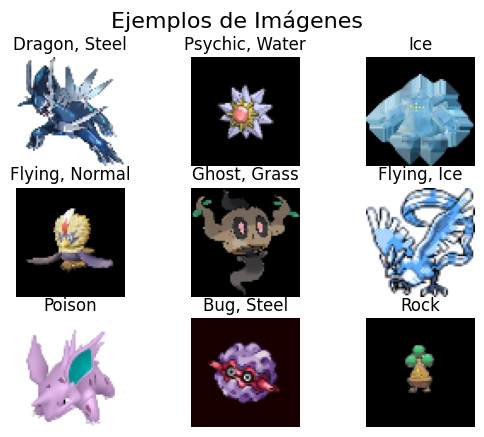

In [ ]:
IMG_SIZE = 64
NUM_CLASSES = 18
BATCH_SIZE = 16

IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    # Normalizar
    image = image / 255.0

    return image, label

    plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img_path = X_train_paths[i]
    label = y_train[i]

    image, _ = load_and_preprocess(img_path, label, augment=True)
    plt.imshow(image.numpy())

    tipos_pokemon = [classes[idx] for idx, val in enumerate(label) if val == 1]
    plt.title(", ".join(tipos_pokemon))
    plt.axis("off")
plt.suptitle("Ejemplos de Imágenes", fontsize=16)
plt.show()

In [ ]:
# --- Pipeline de Entrenamiento ---
train_ds = tf.data.Dataset.from_tensor_slices((X_train_paths, y_train))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=True),
    num_parallel_calls=AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=len(X_train_paths))
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)

# --- Pipeline de Validación ---
val_ds = tf.data.Dataset.from_tensor_slices((X_val_paths, y_val))
val_ds = val_ds.map(
    lambda x, y: load_and_preprocess(x, y, augment=False),
    num_parallel_calls=AUTOTUNE
)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print("✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.")
print(f"   -> train_ds: {train_ds}")
print(f"   -> val_ds:   {val_ds}")
print("✅ Funciones de Transfer Learning listas.")

✅ Pipelines de Entrenamiento (train_ds) y Validación (val_ds) creados.
   -> train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>
   -> val_ds:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 18), dtype=tf.int64, name=None))>
✅ Funciones de Transfer Learning listas.


In [ ]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name='data_augmentation')

print("✅ Funciones de Transfer Learning (con MobileNetV2) listas.")

def create_transfer_model(input_shape, classes):
    """
    Crea un modelo MobileNetV2 usando Transfer Learning.
    """

    # --- 1. Cargar la Base Pre-entrenada ---
    base_model = MobileNetV2( # <-- CAMBIO AQUÍ
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # --- 2. Congelar la Base (Inicialmente) ---
    base_model.trainable = False

    print(f"Base del modelo (MobileNetV2) cargada y congelada.")
    print(f"Parámetros de la base (congelados): {base_model.count_params()}")

    # --- 3. Añadir nuestra "Cabeza" (Head) ---
    inputs = Input(shape=input_shape, name='input_layer')
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dropout(0.5, name='head_dropout')(x)
    outputs = Dense(
        num_classes,
        activation='sigmoid',
        name='fc_pokemon'
    )(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model, base_model

✅ Funciones de Transfer Learning (con MobileNetV2) listas.


In [ ]:
# Crear el modelo. Ahora devuelve el modelo y la base
model, base_model = create_transfer_model(input_shape=IMG_SHAPE, classes=NUM_CLASSES)

# Compilar para la FASE 1
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

# Callbacks
early_stopping = EarlyStopping(
    monitor='recall',
    patience=20,
    verbose=1,
    restore_best_weights=True
)
callbacks_list = [early_stopping]

print("✅ Modelo MobileNetV2 compilado para FASE 1 (Entrenando la cabeza).")
model.summary()

/tmp/ipython-input-2924060814.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2( # <-- CAMBIO AQUÍ


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base del modelo (MobileNetV2) cargada y congelada.
Parámetros de la base (congelados): 2257984
✅ Modelo MobileNetV2 compilado para FASE 1 (Entrenando la cabeza).


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_pokemon (Dense)              │ (None, 18)             │        23,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,281,042 (8.70 MB)

 Trainable params: 23,058 (90.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("--- INICIANDO FASE 1: ENTRENANDO LA CABEZA (MobileNetV2) ---")
# Entrenamos solo la cabeza por unas épocas
history_fase1 = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("\n--- INICIANDO FASE 2: FINE-TUNING (MobileNetV2) ---")

# --- Descongelar el modelo base ---
base_model.trainable = True

# MobileNetV2 tiene 154 capas. Congelemos las primeras 100.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Descongelando modelo base desde la capa {fine_tune_at}.")

# --- Re-compilar el modelo ---
model.compile(optimizer=Adam(learning_rate=1e-5), # Learning rate MUY bajo
              loss='binary_crossentropy',
              metrics=[
                  BinaryAccuracy(name='accuracy'),
                  Precision(name='precition'),
                  Recall(name='recall')
              ])

print("✅ Modelo re-compilado para FASE 2 (Fine-Tuning).")
model.summary()

# --- Continuar el entrenamiento ---
history_fase2 = model.fit(
    train_ds,
    epochs=300,
    initial_epoch=history_fase1.epoch[-1],
    validation_data=val_ds,
    callbacks=callbacks_list
)

print("🚀 ¡Entrenamiento completado (Fase 1 y 2)!")

--- INICIANDO FASE 1: ENTRENANDO LA CABEZA (MobileNetV2) ---
Epoch 1/25
754/754 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.8904 - loss: 0.3549 - precition: 0.1454 - recall: 0.0499 - val_accuracy: 0.9176 - val_loss: 0.2772 - val_precition: 0.5946 - val_recall: 0.0244
Epoch 2/25
754/754 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.9149 - loss: 0.2820 - precition: 0.3865 - recall: 0.0510 - val_accuracy: 0.9185 - val_loss: 0.2691 - val_precition: 0.6364 - val_recall: 0.0435
Epoch 3/25
754/754 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9151 - loss: 0.2771 - precition: 0.4256 - recall: 0.0634 - val_accuracy: 0.9185 - val_loss: 0.2643 - val_precition: 0.6604 - val_recall: 0.0393
Epoch 4/25
754/754 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - accuracy: 0.9157 - loss: 0.2723 - precition: 0.4441 - recall: 0.0692 - val_accuracy: 0.9184 - val_loss: 0.2648 - val_precition: 0.6468 - val_recall: 0.0386
Epoch 5/25
754/754 ━━━━━━━━━━━━━━━━━━━━ 35s 26ms/step - accuracy: 0.9156 - loss: 0.2704 - p

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_pokemon (Dense)              │ (None, 18)             │        23,058 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,281,042 (8.70 MB)

 Trainable params: 1,884,498 (7.19 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 19/100
754/754 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.8961 - loss: 0.5195 - precition: 0.1635 - recall: 0.0614 - val_accuracy: 0.9150 - val_loss: 0.4327 - val_precition: 0.4324 - val_recall: 0.0723
Epoch 20/100
754/754 ━━━━━━━━━━━━━━━━━━━━ 78s 40ms/step - accuracy: 0.8908 - loss: 0.3776 - precition: 0.1778 - recall: 0.0869 - val_accuracy: 0.9142 - val_loss: 0.3912 - val_precition: 0.4108 - val_recall: 0.0756
Epoch 21/100
754/754 ━━━━━━━━━━━━━━━━━━━━ 51s 48ms/step - accuracy: 0.8994 - loss: 0.3337 - precition: 0.2091 - recall: 0.0765 - val_accuracy: 0.9152 - val_loss: 0.3339 - val_precition: 0.4378 - val_recall: 0.0710
Epoch 22/100
754/754 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - accuracy: 0.9074 - loss: 0.3110 - precition: 0.2546 - recall: 0.0628 - val_accuracy: 0.9162 - val_loss: 0.3071 - val_precition: 0.4634 - val_recall: 0.0548
Epoch 23/100
754/754 ━━━━━━━━━━━━━━━━━━━━ 45s 40ms/step - accuracy: 0.9104 - loss: 0.3023 - precition: 0.2755 - recall: 0.0478 - val_accuracy: 0


Generando cuadrícula de imágenes aleatorias del set de entrenamiento...
Cuadrícula de imágenes guardada como: grid_imagenes_entrenamiento.png


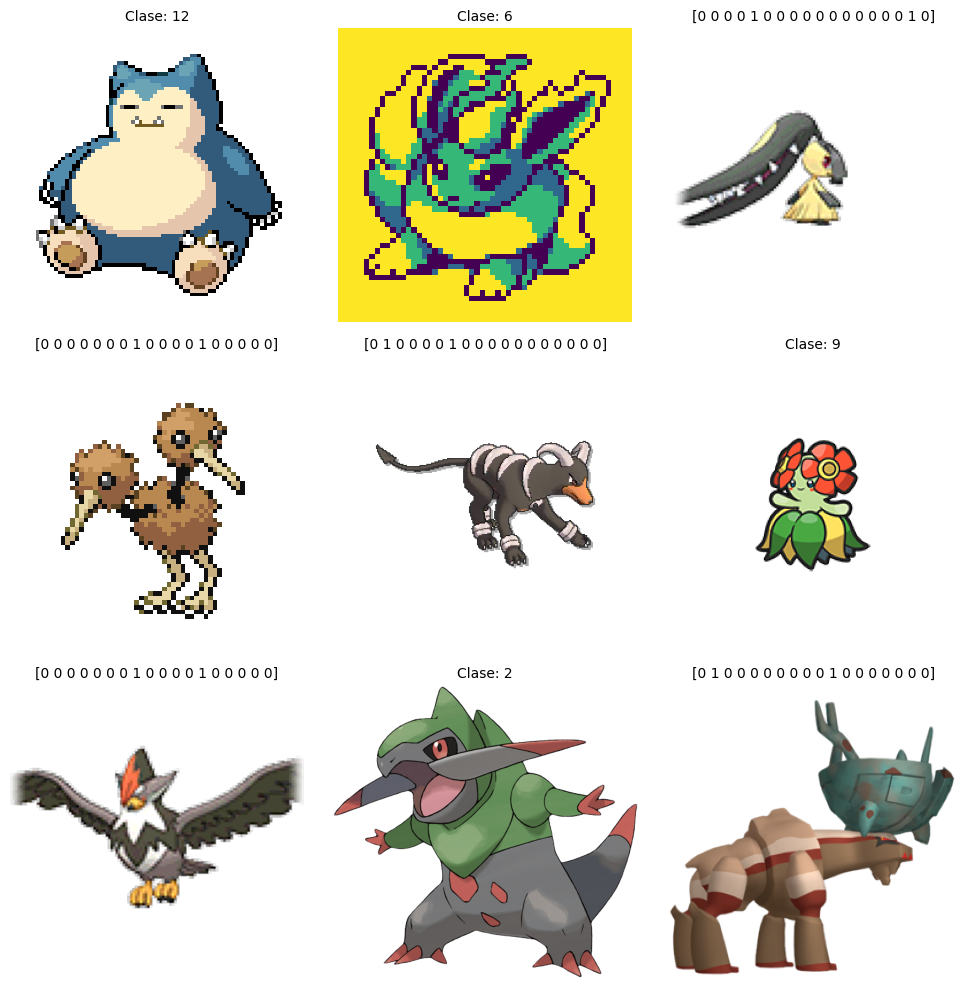

In [ ]:
print("\nGenerando cuadrícula de imágenes aleatorias del set de entrenamiento...")

# Definir el tamaño de la cuadrícula
filas = 3
columnas = 3
num_imagenes = filas * columnas

# Crear la figura y los ejes para la cuadrícula
# figsize ajusta el tamaño total de la imagen
fig, axes = plt.subplots(filas, columnas, figsize=(10, 10))

# Obtener 9 índices aleatorios únicos del conjunto de entrenamiento
# Usamos `random.sample` para asegurar que no haya duplicados
try:
    indices_aleatorios = random.sample(range(len(X_train_paths)), k=num_imagenes)
except ValueError:
    print(f"Error: No tienes suficientes imágenes ({len(X_train_paths)}) para una cuadrícula de {num_imagenes}.")
    # En este caso, simplemente salimos o ajustamos num_imagenes
    indices_aleatorios = [] # Salir

if indices_aleatorios:
    # Aplanar el array de ejes (de 2D a 1D) para iterar fácilmente
    for i, ax in enumerate(axes.flat):
        # Obtener el índice aleatorio
        idx = indices_aleatorios[i]

        # Obtener la ruta de la imagen y la etiqueta
        img_path = X_train_paths[idx]
        label = y_train[idx]

        try:
            # Cargar la imagen desde la ruta
            img = mpimg.imread(img_path)

            # Mostrar la imagen en el eje (subplot)
            ax.imshow(img)

            # --- Formatear el título (etiqueta) ---
            # 'y_train' proviene de 'y_binarized', por lo que puede ser un array one-hot
            # (ej. [0, 1, 0, 0]) o un solo número.
            # Este código intenta manejar ambos casos.
            label_str = ""
            if isinstance(label, (np.ndarray, list)):
                # Si es one-hot, encontramos el índice del '1'
                if np.sum(label) == 1:
                    label_str = f"Clase: {np.argmax(label)}"
                else: # Si es otra cosa (ej. multi-label)
                    label_str = str(label)
            else: # Si es un solo número o string
                label_str = f"Clase: {label}"

            ax.set_title(label_str, fontsize=10)

            # Ocultar los ejes (ticks, labels, etc.)
            ax.axis('off')

        except FileNotFoundError:
            print(f"Error: No se pudo encontrar el archivo {img_path}")
            ax.set_title("Archivo no encontrado", fontsize=8)
            ax.axis('off')
        except Exception as e:
            print(f"Error al cargar {img_path}: {e}")
            ax.set_title("Error de carga", fontsize=8)
            ax.axis('off')

    # Ajustar el espaciado para que los títulos no se superpongan
    plt.tight_layout()

    # Guardar la figura en un archivo
    output_filename = "grid_imagenes_entrenamiento.png"
    plt.savefig(output_filename)
    print(f"Cuadrícula de imágenes guardada como: {output_filename}")

    plt.show()
else:
    print("No hay suficientes imágenes para generar la cuadrícula.")

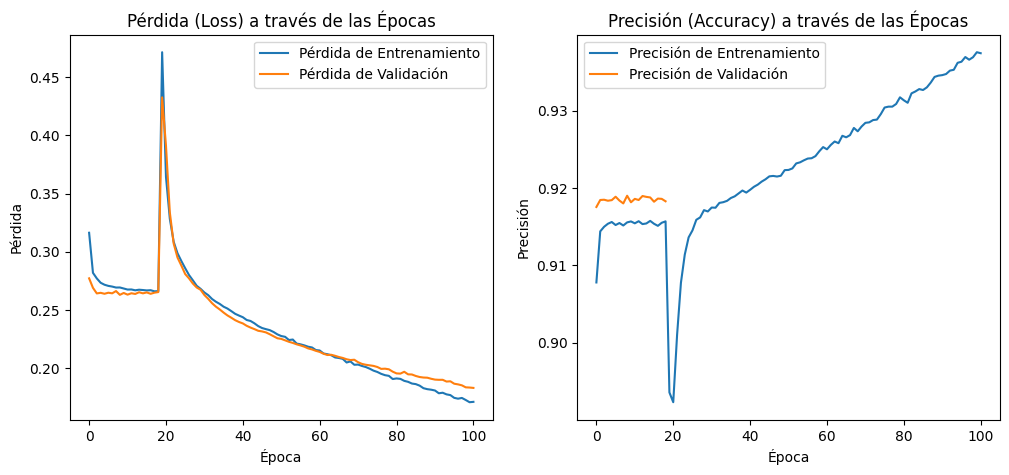

In [ ]:
history_combined = {}

# Concatenar las métricas de la fase 1 y la fase 2
history_combined['loss'] = history_fase1.history['loss'] + history_fase2.history['loss']
history_combined['val_loss'] = history_fase1.history['val_loss'] + history_fase2.history['val_loss']
history_combined['accuracy'] = history_fase1.history['accuracy'] + history_fase2.history['accuracy']
history_combined['val_accuracy'] = history_fase1.history['val_accuracy']

# --- Graficar ---

plt.figure(figsize=(12, 5))

# Graficar Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history_combined['loss'], label='Pérdida de Entrenamiento')
plt.plot(history_combined['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida (Loss) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

# Graficar Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history_combined['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history_combined['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión (Accuracy) a través de las Épocas')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.show()

189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


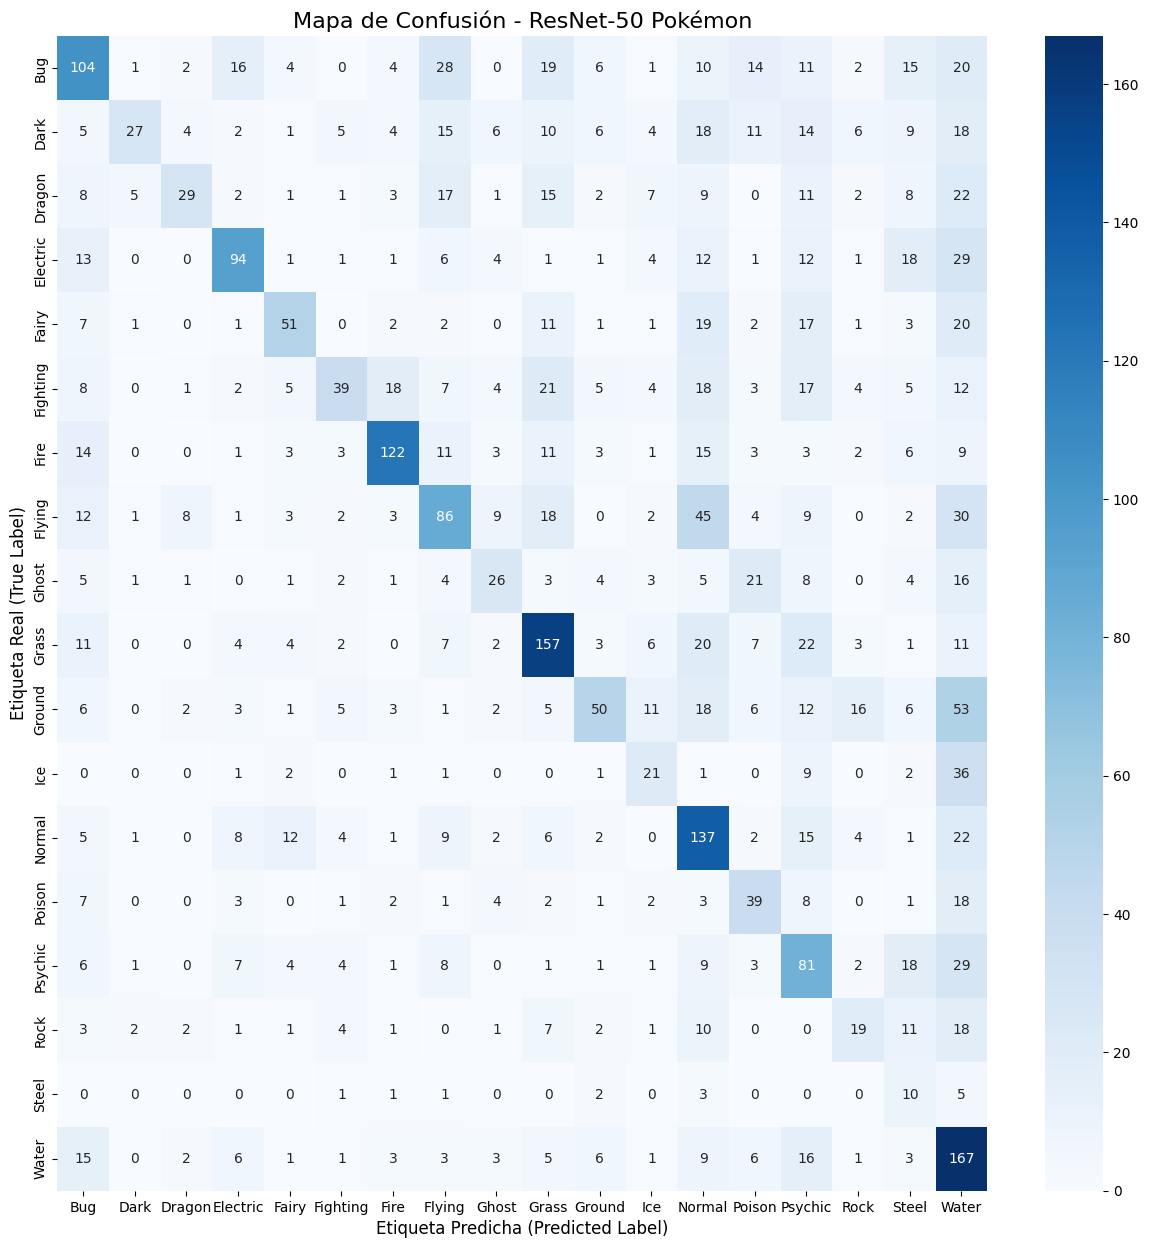

In [ ]:
# Matriz de confusion
plt.figure(figsize=(15, 15))
y_pred_probs = model.predict(val_ds)
y_pred_indices = np.argmax(y_pred_probs, axis=1)
y_true_indices = np.argmax(np.array(list(y_val)), axis=1)

cm = confusion_matrix(y_true_indices, y_pred_indices)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title('Mapa de Confusión - ResNet-50 Pokémon', fontsize=16)
plt.ylabel('Etiqueta Real (True Label)', fontsize=12)
plt.xlabel('Etiqueta Predicha (Predicted Label)', fontsize=12)

plt.show()


In [ ]:
# --- 1. Generar predicciones (usando el modelo 'sigmoid' entrenado) ---
y_pred_probs = model.predict(val_ds)

# --- 2. Convertir probabilidades a etiquetas ---
# 'sigmoid' nos da probabilidades (0.0 a 1.0) para cada clase.
# Decidimos que cualquier cosa por encima del 50% (0.5) es un "Sí".
y_pred = (y_pred_probs > 0.5).astype(int)

# --- 3. Generar el reporte ---
# 'y_val' son las etiquetas reales, 'y_pred' son las que dijo el modelo
# 'class_names' es tu lista de 18 nombres de Pokémon
print(classification_report(y_val, y_pred, target_names=classes))

189/189 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step
              precision    recall  f1-score   support

         Bug       0.56      0.42      0.48       257
        Dark       0.77      0.15      0.24       165
      Dragon       0.72      0.19      0.30       154
    Electric       0.75      0.49      0.59       215
       Fairy       0.67      0.41      0.51       150
    Fighting       0.64      0.19      0.30       196
        Fire       0.85      0.52      0.65       247
      Flying       0.69      0.45      0.55       351
       Ghost       0.76      0.26      0.39       142
       Grass       0.76      0.57      0.65       356
      Ground       0.75      0.25      0.37       277
         Ice       0.70      0.40      0.51       126
      Normal       0.68      0.48      0.57       391
      Poison       0.74      0.35      0.47       297
     Psychic       0.66      0.36      0.46       285
        Rock       0.86      0.29      0.43       209
       Steel       0.60      0.36      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
